In [ ]:
#| default_exp pr_classification_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

# Pairwise Relation Classification

## Classification Accuracy
> of a binary [classification problem](./module_functions_ex.ipynb#classif_problem). A class contains pairwise relation embeddings (rows in a pairwise relation matrix) of time series that are synchronized, i.e., belong to the same segment of the underlying `Datasource` object.

#### The primary embedding `features`

In [ ]:
#| eval: false
from fhemb.utils.cutils import prepare_data, calc_and_save_pr_accuracy, plot_accuracy_summary

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-04 17:57:31.424205: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more

In [ ]:
#| eval: false
from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'title': 'Don Giovanni', 'time_interval': (14200, 15200)}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]
 [INFO] piece._load_from_db: Loading face_t fro

In [ ]:
#| eval: false

emb_prj_decomp_rec1.features

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']


{'percentiles_ts': ('p20', 'p80'),
 'binheights_ts': ('bh1', 'bh2', 'bh3'),
 'pcomponents_ts': ('pc0', 'pc1', 'pc2'),
 'features_ts': ('skew', 'kurtosis')}

### Calculate and store

#### Distance correlation

In [ ]:
dirname_dcor = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_dcor_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():    #                 
    for feature in features:                                        #
                                      # iterate over this list of features of the EmbeddingCollection object 
        print(f"Embedding: {embedding}, Feature: {feature}")
        X, y = prepare_data(                                                      # prepare the matrix X and label vector y for the two groups
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T, # first 500 samples for group 0
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T  # last 500 samples for group 1
        )
        print(f"Shape: {X.shape}")            # matrix (n_samples x n_dataframes)
        filename=calc_and_save_pr_accuracy(   # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename  
            X[y==0],                          # group 0
            X[y==1],                          # group 1
            dirname=dirname_dcor,             # directory in which the results Excel file will be stored
            alignment_type='dcor',            # alignment method for distance matrix computation
            normalize='minmax',               # normalize after splitting the data into train and test sets
            radius=1,                         # refinement window size in fastdtw (only used for fastdtw)
            feature=feature,                  # feature name for labeling the results
            random_states=10                  # number of random states for train/test splits in classification
        )
        print(f"Saved results to: {filename}")


 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p20
 [DEBUG] embedding.get_ts_subjs: Available features: ('p20', 'p80')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p20
 [DEBUG] embedding.get_ts_subjs: Available features: ('bh1', 'bh2', 'bh3')
 [WARNING] embedding.get_ts_subjs_ftr: Feature p20 not in features: ('bh1', 'bh2', 'bh3')
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p20
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for f

Embedding: percentiles_ts, Feature: p20
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:14<00:00, 68.94it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:00<00:00, 4889.87it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.35
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.50
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_dcor_minmax/acc_summ_p20.xlsx
Embedding: percentiles_ts, Feature: p80
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:00<00:00, 4811.61it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:00<00:00, 4742.58it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.65
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.

...

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_dcor_minmax/acc_summ_pc2.xlsx
Embedding: features_ts, Feature: skew
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:00<00:00, 4127.71it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:00<00:00, 4254.39it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.45
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_dcor_minmax/acc_summ_skew.xlsx
Embedding: features_ts, Feature: kurtosis
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:00<00:00, 4634.01it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:00<00:00, 3617.81it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.55
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_dcor_minmax/acc_summ_kurtosis.xlsx


#### FastDTW
> uses various distance metrics as a similarity metric when computing the distance matrix 

In [ ]:
dirname_fast = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_fast_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():    #                 
    for feature in features:                                        #
        if feature in ['pc1', 'pc2']:                               # iterate over this list of features of the EmbeddingCollection object 
            print(f"Embedding: {embedding}, Feature: {feature}")
            X, y = prepare_data(                                                      # prepare the matrix X and label vector y for the two groups
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T, # first 500 samples for group 0
                emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T  # last 500 samples for group 1
            )
            print(f"Shape: {X.shape}")            # matrix (n_samples x n_dataframes)
            filename=calc_and_save_pr_accuracy(   # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename  
                X[y==0],                          # group 0
                X[y==1],                          # group 1
                dirname=dirname_fast,             # directory in which the results Excel file will be stored
                alignment_type='fastdtw',         # alignment method for distance matrix computation
                normalize='minmax',               # normalize after splitting the data into train and test sets
                radius=1,                         # refinement window size in fastdtw (only used for fastdtw)
                feature=feature,                  # feature name for labeling the results
                random_states=10                  # number of random states for train/test splits in classification
            )
            print(f"Saved results to: {filename}")
        else:
            print(f"Skipping Embedding: {embedding}, Feature: {feature} for fastdtw")    

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for pc1
 [DEBUG] embedding.get_df_ts_

Skipping Embedding: percentiles_ts, Feature: p20 for fastdtw
Skipping Embedding: percentiles_ts, Feature: p80 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh1 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh2 for fastdtw
Skipping Embedding: binheights_ts, Feature: bh3 for fastdtw
Skipping Embedding: pcomponents_ts, Feature: pc0 for fastdtw
Embedding: pcomponents_ts, Feature: pc1
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:53<00:00, 18.42it/s]
 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [01:14<00:00, 11.87it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.30
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc1.xlsx
Embedding: pcomponents_ts, Feature: pc2
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:43<00:00, 22.68it/s]
 [INFO] cutils.calc_pairwise_relation: Using euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:39<00:00, 22.41it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.70
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.70
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_fast_minmax/acc_summ_pc2.xlsx
Skipping Embedding: features_ts, Feature: skew for fastdtw
Skipping Embedding: features_ts, Feature: kurtosis for fastdtw


#### Soft DTW
> uses the squared Euclidean distance as a similarity metric when computing the distance matrix

In [ ]:
#| eval: false

dirname_soft = 'dtw_accuracy' + '_emb_prj_decomp_rec1' + '_soft_minmax'

In [ ]:
#| eval: false

for embedding, features in emb_prj_decomp_rec1.features.items():   # iterate over all features of the EmbeddingCollection object 
    for feature in features:                                       # 
        print(f"Embedding: {embedding}, Feature: {feature}")
        X, y = prepare_data(                                                        # prepare the matrix X and label vector y for the two groups
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[:500].T,   # first 500 samples for group 0
            emb_prj_decomp_rec1.get_df_ts_subjs(feature)[embedding].iloc[500:].T    # last 500 samples for group 1
        )
        print(f"Shape: {X.shape}")           # matrix (n_samples x n_dataframes)
        filename=calc_and_save_pr_accuracy(  # compute the classification accuracy across multiple classifiers and primary embeddings, save results to Excel file and return the filename 
            X[y==0],                         # group 0
            X[y==1],                         # group 1
            dirname=dirname_soft,            # directory in which the results Excel file will be stored
            alignment_type='soft_dtw',       # alignment method for distance matrix computation
            normalize='minmax',              # normalize after splitting the data into train and test sets
            feature=feature,                 # feature name for labeling the results
            random_states=10                 # number of random states for train/test splits in classification    
        )
        print(f"Saved results to: {filename}")

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'features' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p20
 [DEBUG] embedding.get_df_ts_

Embedding: percentiles_ts, Feature: p20
Shape: (64, 500)


Computing distances:   0%|          | 0/990 [00:00<?, ?it/s]/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks.

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_p20.xlsx
Embedding: percentiles_ts, Feature: p80
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:04<00:00, 200.50it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using tslearn Soft-DTW with default squared euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:04<00:00, 201.20it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.70
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radn

...

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_pc2.xlsx
Embedding: features_ts, Feature: skew
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:04<00:00, 245.68it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using tslearn Soft-DTW with default squared euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:03<00:00, 268.58it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.70
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.35
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.60
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.65
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radn

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_skew.xlsx
Embedding: features_ts, Feature: kurtosis
Shape: (64, 500)


Computing distances: 100%|██████████| 990/990 [00:03<00:00, 276.88it/s]
 [DEBUG] cutils.calc_pairwise_relation: Using tslearn Soft-DTW with default squared euclidean alignment metric
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for asymmetric data
Computing distances: 100%|██████████| 880/880 [00:03<00:00, 275.27it/s]
 [INFO] cutils.calc_accuracies: Accuracy of randf: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with linear kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with precomputed kernel: 0.45
 [INFO] cutils.calc_accuracies: Accuracy of SVM with poly kernel: 0.40
 [INFO] cutils.calc_accuracies: Accuracy of SVM with sigmoid kernel: 0.50
 [INFO] cutils.calc_accuracies: Accuracy of SVM with rbf kernel: 0.45
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radn

Saved results to: /Users/radned/Projects/ttsembedding/dtw_accuracy_emb_prj_decomp_rec1_soft_minmax/acc_summ_kurtosis.xlsx


### Retrieve and visualize
> Accuracy of multiple classifiers on various landmark embeddings

In [ ]:
#| eval: false

COLUMNS_FILTER=[                     # list of classifier columns to include in the visualization
        'knn_precomputed', 
        'knn_cosine', 
        'knn_l1', 
        'knn_euclidean', 
        'knn_minkowski', 
        'rotf', 
        'randf', 
        'svm_precomputed', 
        'svm_rbf', 
        'svm_poly', 
        'svm_linear'
    ]

#### Distance correlation

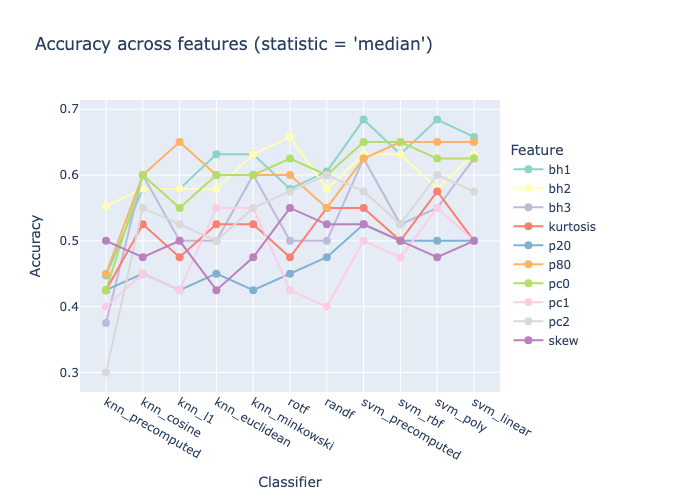

In [ ]:
#| eval: false

plot_accuracy_summary(                       # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` 
    dirname_dcor,                            # directory from which the results are loaded
    features=['pc0', 'pc1','pc2', 'bh1', 'bh2', 'bh3', 'skew', 'kurtosis', 'p20', 'p80'],  # the features of the primary embeddings for which the accuracy will be visualized      
    statistics='median',                     # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    columns_filter=COLUMNS_FILTER,           # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                             # for debugging
);

#### FastDTW

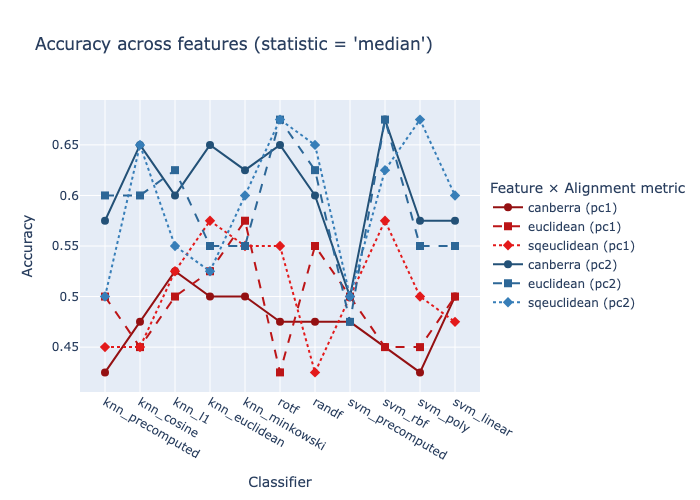

In [ ]:
#| eval: false

plot_accuracy_summary(                   # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` and  `dtw_filter` 
    dirname_fast,                        # directory from which the results are loaded
    features=['pc2', 'pc1'],             # the features of the primary embeddings for which the accuracy will be visualized
    statistics='median',                 # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    dtw_filter=[                         # list of DTW alignment distance metrics to include in the visualization
        'euclidean', 
        'sqeuclidean', 
        'canberra'
    ],          
    columns_filter=COLUMNS_FILTER,       # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                         # for debugging
);

#### SoftDTW

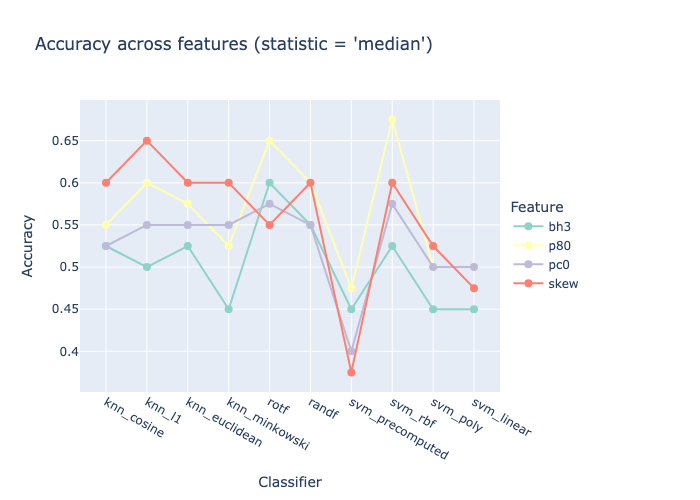

In [ ]:
#| eval: false

plot_accuracy_summary(                       # visualize the `statistics` of the classification accuracy of multiple classifiers (`column_filter`) across `features` 
    dirname_soft,                            # directory from which the results are loaded
    features=['p80', 'bh3', 'pc0', 'skew'],  # the features of the primary embeddings for which the accuracy will be visualized      
    statistics='median',                     # statistic to aggregate accuracy across multiple random states ('median', 'mean', 'std', 'iqr')
    columns_filter=COLUMNS_FILTER,           # list of classifier columns to include in the visualization (e.g., ['knn_precomputed', 'svm_rbf'])
    verbose=True                             # for debugging
);